---
# Metody oparte na sąsiedztwie
---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import numpy as np

from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

In [2]:
sklearn.set_config(transform_output="pandas")
sklearn.__version__

'1.7.2'

# Przykład - [Yeast](https://archive.ics.uci.edu/dataset/110/yeast)

Tym razem zajmiemy się problemem klasyfikacji na przykładzie prognozowania miejsc lokalizacji komórkowej białek

## Załadowanie danych

In [16]:
yeast = fetch_ucirepo(id=110) 
X = yeast.data.features 
y = yeast.data.targets 

In [17]:
X.shape, len(y)

((1484, 8), 1484)

## Wstępne przetwarzanie danych

### Brakujące dane

In [18]:
X[pd.isna(X).any(axis=1)]

,mcg,gvh,alm,mit,erl,pox,vac,nuc


### Zmienne katagoryczne

#### Rzadkie kategorie
Niektóre kategorie mają mało przykładów, ale usuńmy tylko skrajną tj. `ERL`

In [19]:
y.value_counts()

localization_site
CYT                  463
NUC                  429
MIT                  244
ME3                  163
ME2                   51
ME1                   44
EXC                   35
VAC                   30
POX                   20
ERL                    5
Name: count, dtype: int64

In [7]:
idx_to_drop = y[y['localization_site'] == 'ERL'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

<span style="color:red">**Ćwiczenie:**</span> użyj `OrdinalEncoder` do usunięcia rzadkiej kategorii.

In [20]:
encoder = OrdinalEncoder()

y_enc = encoder.fit_transform(y[['localization_site']])
y_enc = y_enc.to_numpy().ravel()

erl_code = list(encoder.categories_[0]).index('ERL')

idx_to_drop = y.index[y_enc == erl_code]

X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

#### Kodowanie katagorii
Tym razem używamy [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) a nie `one-hot encoder`!

In [21]:
label_encoder = LabelEncoder()

In [22]:
y_trans = label_encoder.fit_transform(y['localization_site'].values)

### Standardyzacja / normalizacja
Na początek, wybieramy standardowe skalowanie:

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Klasyfikator kNN

### Podział danych na zbiór treningowy i testowy

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_trans, stratify=y_trans,
                                                    test_size=0.1, random_state=0)

<span style="color:red">**Ćwiczenie:**</span> co się stanie, gdy nie podamy parametru `stratify`?

Bez parametru stratify podział danych jest całkowicie losowy, co może prowadzić do zaburzenia proporcji klas w zbiorach treningowym i testowym. W efekcie model może być trenowany na niereprezentatywnych danych, a jego ocena może być niewiarygodna, szczególnie w przypadku rzadkich klas.

### Dostrajamy model
- Używamy domyślnych hiperparametrów - zawsze warto od nich zacząć
- Zauważmy, że model nie jest formalnie trenowany

In [25]:
knn = KNeighborsClassifier(n_jobs=-1)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,-1


### Sprawdzamy wyniki

In [26]:
y_pred_train = knn.predict(X_train)
y_pred_test  = knn.predict(X_test)

#### f1-score

In [27]:
f1_score(y_train, y_pred_train, average='weighted'), \
f1_score(y_test, y_pred_test, average='weighted')

(0.6700505005259814, 0.5387392349820613)

In [28]:
f1_score(y_train, y_pred_train, average='micro'), \
f1_score(y_test, y_pred_test, average='micro')

(0.6791885800150262, 0.5540540540540541)

In [29]:
f1_score(y_train, y_pred_train, average='macro'), \
f1_score(y_test, y_pred_test, average='macro')

(0.6017077890637409, 0.38479633045630174)

- Wynik na zbiorze treningowym jest poniżej oczekiwań
- Wynik na zbiorze testowym jest wyrażnie gorszy, niż na zbiorze treningowym

#### Macierz pomyłek
Macierz ta pozwala lepiej zrozumieć, z jakimi kategoriami model ma problem

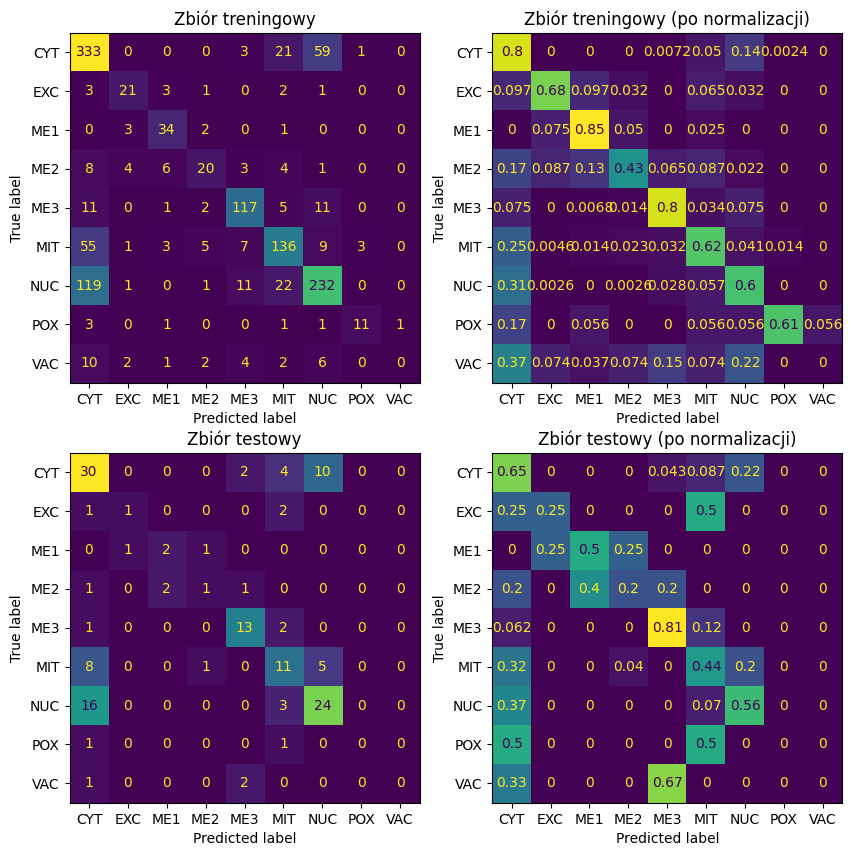

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
kwargs = {'colorbar': None, 'display_labels': label_encoder.classes_}
labels = ['Zbiór treningowy', 'Zbiór testowy']
for i, (y1, y2) in enumerate(zip([y_train, y_test], [y_pred_train, y_pred_test])):
    ConfusionMatrixDisplay.from_predictions(y1, y2, ax=ax[i, 0], **kwargs)
    ConfusionMatrixDisplay.from_predictions(y1, y2, ax=ax[i, 1], normalize="true", **kwargs)
    ax[i, 0].set_title(f"{labels[i]}")
    ax[i, 1].set_title(f"{labels[i]} (po normalizacji)")
plt.show()

- Widać, że mamy poważny problem z klasyfikacją kategorii MIT i NUC
- Mało tego, problem pojawia się już podczas treningu